In [1]:
import pandas as pd

from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("CSV loaded successfully!")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

CSV loaded successfully!
Rows: 7043
Columns: 21


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print("Column Names:")

for column in df.columns:
    print(column)

Column Names:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [6]:
missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 7043
Number of columns: 21


In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges converted successfully!")

TotalCharges converted successfully!


In [9]:
missing_values = df.isnull().sum()

print(missing_values)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
missing_values = df.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ]
)

TotalCharges    11
dtype: int64


In [12]:
df = df.dropna(
    subset=["TotalCharges"]
)

print("Missing TotalCharges removed.")
print("New dataset shape:", df.shape)

Missing TotalCharges removed.
New dataset shape: (7032, 21)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [14]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [15]:
print(df["Churn"].unique())

['No' 'Yes']


In [16]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [17]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_percentage.round(2))

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


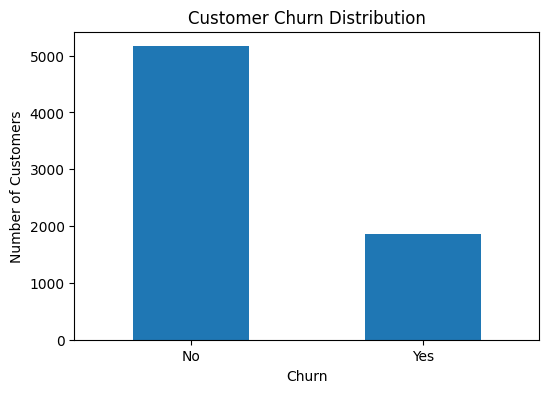

In [18]:

import matplotlib.pyplot as plt
churn_counts = df["Churn"].value_counts()
plt.figure(figsize=(6, 4))

churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [19]:
print(churn_counts)
print(churn_percentage.round(2))

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_columns].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [22]:
print(
    df["SeniorCitizen"].value_counts()
)

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64


In [23]:
for column in df.columns:
    print(
        column,
        ":",
        df[column].nunique(),
        "unique values"
    )

customerID : 7032 unique values
gender : 2 unique values
SeniorCitizen : 2 unique values
Partner : 2 unique values
Dependents : 2 unique values
tenure : 72 unique values
PhoneService : 2 unique values
MultipleLines : 3 unique values
InternetService : 3 unique values
OnlineSecurity : 3 unique values
OnlineBackup : 3 unique values
DeviceProtection : 3 unique values
TechSupport : 3 unique values
StreamingTV : 3 unique values
StreamingMovies : 3 unique values
Contract : 3 unique values
PaperlessBilling : 2 unique values
PaymentMethod : 4 unique values
MonthlyCharges : 1584 unique values
TotalCharges : 6530 unique values
Churn : 2 unique values


In [24]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7032
Columns: 21


In [25]:
feature_dictionary = pd.DataFrame({
    "Feature": [
        "customerID",
        "gender",
        "SeniorCitizen",
        "Partner",
        "Dependents",
        "tenure",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ],

    "Business Meaning": [
        "Unique customer identification number",
        "Gender of the customer",
        "Whether the customer is a senior citizen",
        "Whether the customer has a partner",
        "Whether the customer has dependents",
        "Number of months the customer has used the service",
        "Whether the customer has phone service",
        "Whether the customer has multiple phone lines",
        "Type of internet service",
        "Whether online security service is subscribed",
        "Whether online backup service is subscribed",
        "Whether device protection service is subscribed",
        "Whether technical support service is subscribed",
        "Whether streaming TV service is subscribed",
        "Whether streaming movies service is subscribed",
        "Type of customer contract",
        "Whether paperless billing is enabled",
        "Customer payment method",
        "Monthly amount charged to the customer",
        "Total amount charged to the customer",
        "Whether the customer left the company"
    ],

    "Feature Type": [
        "Identifier",
        "Categorical",
        "Binary",
        "Binary",
        "Binary",
        "Numerical",
        "Binary",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Binary",
        "Categorical",
        "Numerical",
        "Numerical",
        "Target"
    ]
})

feature_dictionary

,Feature,Business Meaning,Feature Type
0,customerID,Unique customer identification number,Identifier
1,gender,Gender of the customer,Categorical
2,SeniorCitizen,Whether the customer is a senior citizen,Binary
3,Partner,Whether the customer has a partner,Binary
4,Dependents,Whether the customer has dependents,Binary
5,tenure,Number of months the customer has used the ser...,Numerical
6,PhoneService,Whether the customer has phone service,Binary
7,MultipleLines,Whether the customer has multiple phone lines,Categorical
8,InternetService,Type of internet service,Categorical
9,OnlineSecurity,Whether online security service is subscribed,Categorical


In [26]:
pd.set_option(
    "display.max_rows",
    None
)

display(feature_dictionary)

,Feature,Business Meaning,Feature Type
0,customerID,Unique customer identification number,Identifier
1,gender,Gender of the customer,Categorical
2,SeniorCitizen,Whether the customer is a senior citizen,Binary
3,Partner,Whether the customer has a partner,Binary
4,Dependents,Whether the customer has dependents,Binary
5,tenure,Number of months the customer has used the ser...,Numerical
6,PhoneService,Whether the customer has phone service,Binary
7,MultipleLines,Whether the customer has multiple phone lines,Categorical
8,InternetService,Type of internet service,Categorical
9,OnlineSecurity,Whether online security service is subscribed,Categorical


In [27]:
feature_dictionary.to_csv(
    "feature_dictionary.csv",
    index=False
)

print("Feature dictionary saved successfully!")

Feature dictionary saved successfully!


In [28]:
from google.colab import files

files.download("feature_dictionary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate churn percentage by contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


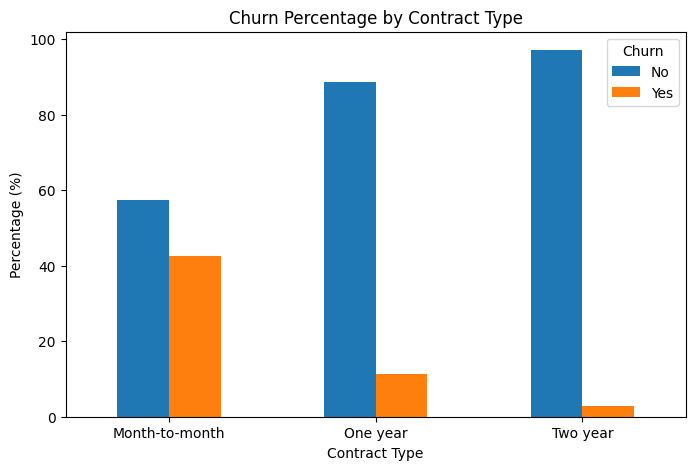

In [30]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [31]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


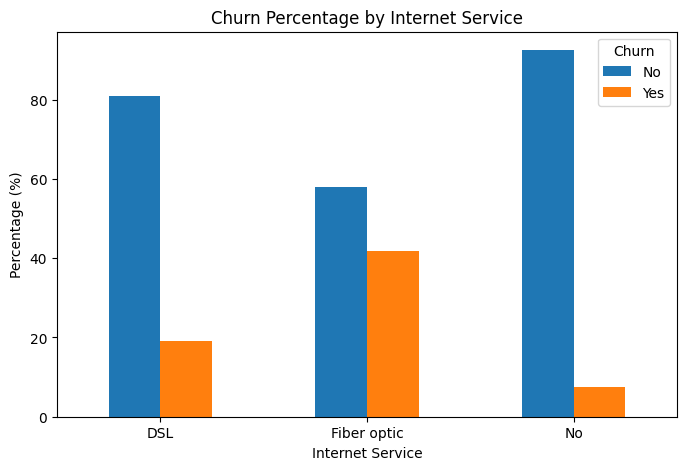

In [32]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Percentage by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [33]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn.round(2))

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.27  16.73
Credit card (automatic)    84.75  15.25
Electronic check           54.71  45.29
Mailed check               80.80  19.20


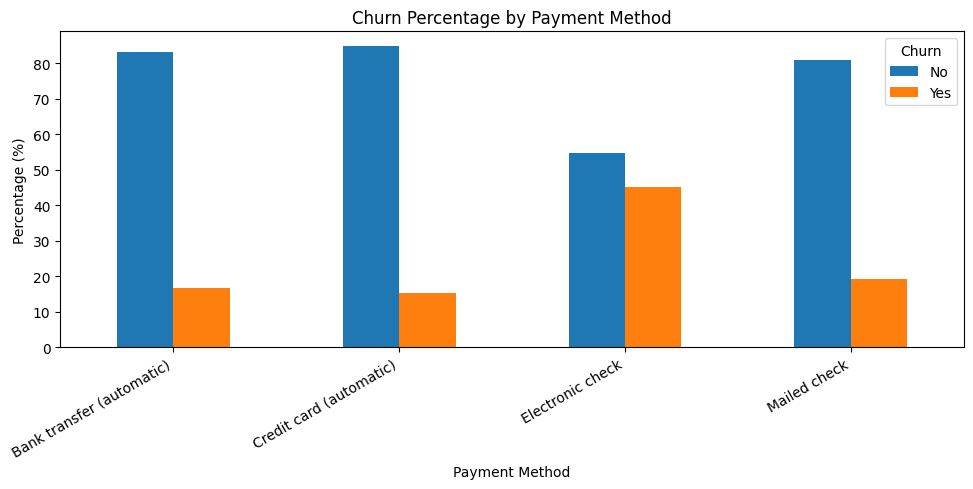

In [34]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Percentage by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [35]:
contract_yes_churn = contract_churn["Yes"].sort_values(
    ascending=False
)

internet_yes_churn = internet_churn["Yes"].sort_values(
    ascending=False
)

payment_yes_churn = payment_churn["Yes"].sort_values(
    ascending=False
)

print("Churn by Contract:")
print(contract_yes_churn.round(2))

print("\nChurn by Internet Service:")
print(internet_yes_churn.round(2))

print("\nChurn by Payment Method:")
print(payment_yes_churn.round(2))

Churn by Contract:
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Yes, dtype: float64

Churn by Internet Service:
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: Yes, dtype: float64

Churn by Payment Method:
PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Name: Yes, dtype: float64


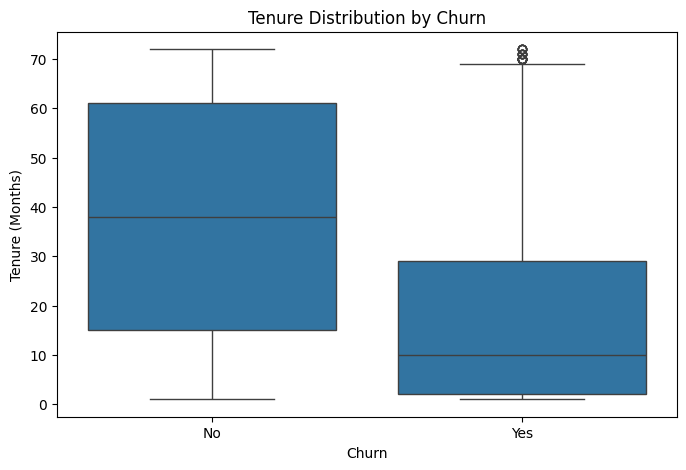

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

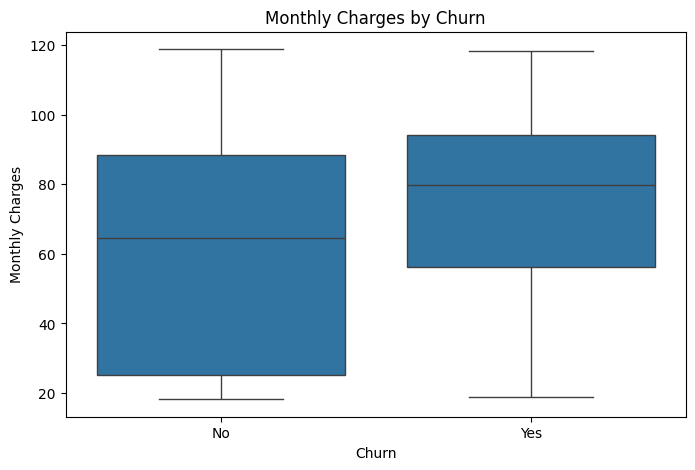

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

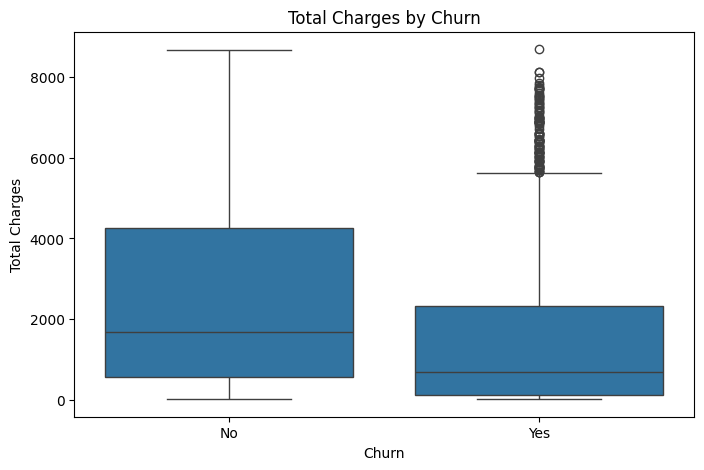

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [39]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

numerical_comparison = df.groupby(
    "Churn"
)[numerical_features].mean()

print(numerical_comparison.round(2))

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.65           61.31       2555.34
Yes     17.98           74.44       1531.80


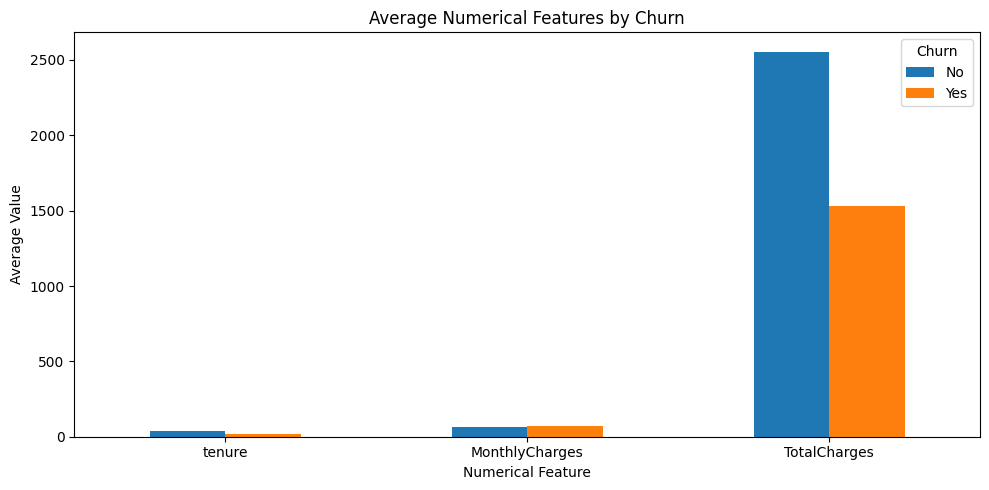

In [40]:
numerical_comparison.T.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Numerical Features by Churn")
plt.xlabel("Numerical Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [41]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print(numerical_columns)

['tenure', 'MonthlyCharges', 'TotalCharges']


In [42]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return {
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    }

In [43]:
outlier_results = []

for column in numerical_columns:
    result = detect_outliers_iqr(df, column)
    outlier_results.append(result)

outlier_df = pd.DataFrame(outlier_results)

display(outlier_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,tenure,9.0000,55.0000,46.0000,-60.00000,124.00000,0
1,MonthlyCharges,35.5875,89.8625,54.2750,-45.82500,171.27500,0
2,TotalCharges,401.4500,3794.7375,3393.2875,-4688.48125,8884.66875,0


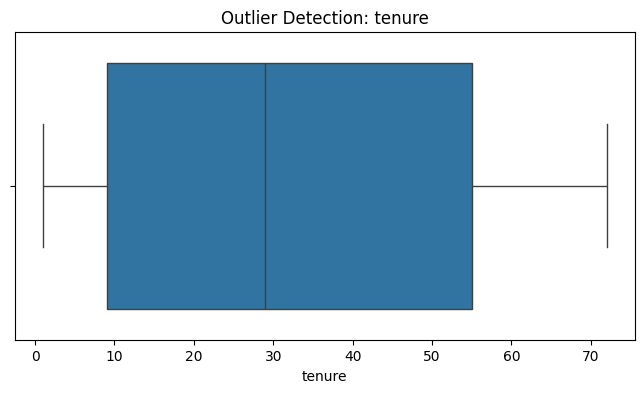

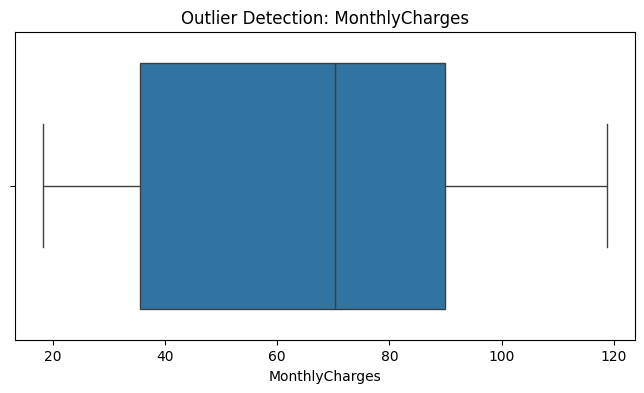

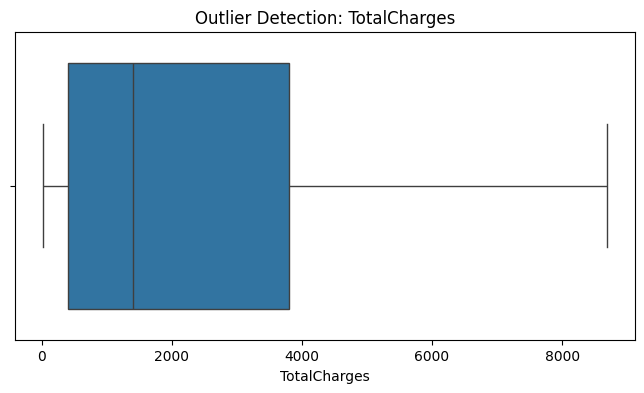

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Outlier Detection: {column}")
    plt.xlabel(column)

    plt.show()

In [45]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Calculate correlation matrix

correlation_matrix = df[
    numerical_columns
].corr()

print(correlation_matrix.round(2))

                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.25          0.83
MonthlyCharges    0.25            1.00          0.65
TotalCharges      0.83            0.65          1.00


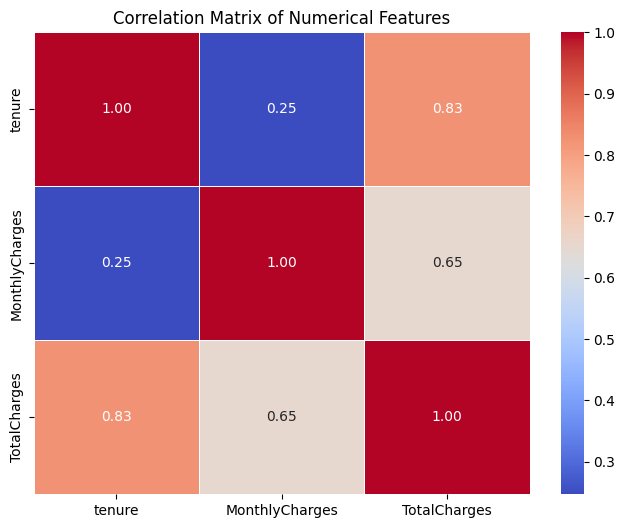

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [47]:
df["Churn_Encoded"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df[["Churn", "Churn_Encoded"]].head())

  Churn  Churn_Encoded
0    No              0
1    No              0
2   Yes              1
3    No              0
4   Yes              1


In [48]:
target_correlation = df[
    numerical_columns + ["Churn_Encoded"]
].corr()["Churn_Encoded"].sort_values(
    ascending=False
)

print(target_correlation.round(3))

Churn_Encoded     1.000
MonthlyCharges    0.193
TotalCharges     -0.199
tenure           -0.354
Name: Churn_Encoded, dtype: float64


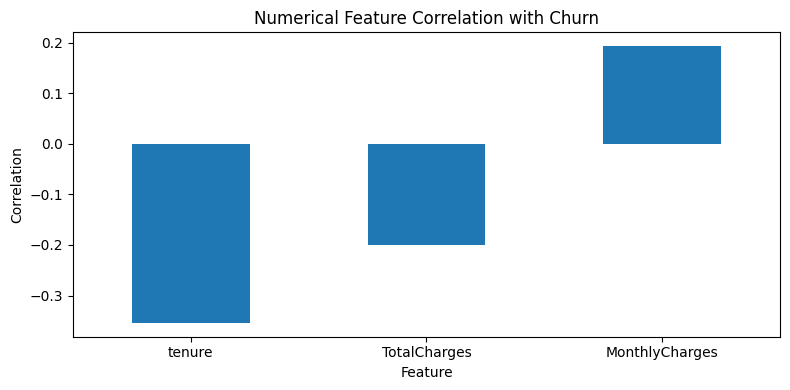

In [49]:
feature_target_correlation = target_correlation.drop(
    "Churn_Encoded"
)

plt.figure(figsize=(8, 4))

feature_target_correlation.sort_values().plot(
    kind="bar"
)

plt.title("Numerical Feature Correlation with Churn")
plt.xlabel("Feature")
plt.ylabel("Correlation")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [50]:

X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Encoded"
    ],
    errors="ignore"
)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [51]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)



numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5625, 19)
Testing features: (1407, 19)
Training target: (5625,)
Testing target: (1407,)


In [54]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully!")

Logistic Regression imported successfully!


In [55]:
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Machine learning pipeline created successfully!")

Machine learning pipeline created successfully!


In [56]:
model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [57]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 1407


In [58]:
y_probability = model.predict_proba(
    X_test
)[:, 1]

print("Probability predictions generated successfully!")
print(y_probability[:10])

Probability predictions generated successfully!
[0.05047676 0.78565521 0.01428964 0.4013745  0.23082895 0.72242587
 0.07302864 0.3490509  0.84579476 0.04683132]


In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [60]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("Model Evaluation Results")
print("------------------------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Model Evaluation Results
------------------------
Accuracy:  0.7257
Precision: 0.4901
Recall:    0.7968
F1-Score:  0.6069
ROC-AUC:   0.8351


In [61]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [62]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[723 310]
 [ 76 298]]


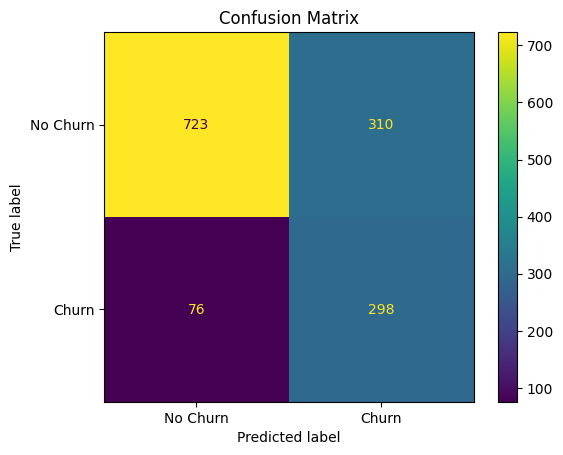

In [63]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [64]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

evaluation_results.to_csv(
    "model_evaluation_results.csv",
    index=False
)

display(evaluation_results)

,Metric,Value
0,Accuracy,0.725657
1,Precision,0.490132
2,Recall,0.796791
3,F1-Score,0.606925
4,ROC-AUC,0.835134


In [65]:
from google.colab import files

files.download(
    "model_evaluation_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
contract_summary = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn by Contract Type:")
display(contract_summary.round(2))

Churn by Contract Type:


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


In [67]:
internet_summary = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn by Internet Service:")
display(internet_summary.round(2))

Churn by Internet Service:


Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


In [69]:
average_summary = df.groupby(
    "Churn"
)[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
].mean()

print("Average Numerical Features:")
display(average_summary.round(2))

Average Numerical Features:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.65,61.31,2555.34
Yes,17.98,74.44,1531.80


In [70]:
df.to_csv(
    "cleaned_telco_churn_dataset.csv",
    index=False
)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [71]:
from google.colab import files

files.download(
    "cleaned_telco_churn_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
import os

project_folder = "Telco_Churn_Project"

os.makedirs(
    project_folder,
    exist_ok=True
)

print("Project folder created!")

Project folder created!


In [73]:
feature_dictionary.to_csv(
    f"{project_folder}/feature_dictionary.csv",
    index=False
)

print("Feature dictionary saved!")

Feature dictionary saved!


In [74]:
evaluation_results.to_csv(
    f"{project_folder}/model_evaluation_results.csv",
    index=False
)

print("Evaluation results saved!")

Evaluation results saved!


In [75]:
df.to_csv(
    f"{project_folder}/cleaned_telco_churn_dataset.csv",
    index=False
)

print("Cleaned dataset saved!")

Cleaned dataset saved!


In [76]:
summary_text = """
TELCO CUSTOMER CHURN ANALYSIS AND PREDICTION
=============================================

1. Business Problem
The telecom company wants to understand customer churn
and identify factors associated with customer attrition.

2. Business Objective
- Analyze customer churn patterns.
- Understand customer characteristics.
- Build a machine learning model.
- Support customer retention strategies.

3. Data Cleaning
- Converted TotalCharges into numeric format.
- Removed records with missing TotalCharges.
- Checked duplicate records.

4. Exploratory Data Analysis
- Analyzed churn distribution.
- Examined contract, internet service, and payment method.
- Studied tenure, MonthlyCharges, and TotalCharges.
- Performed outlier and correlation analysis.

5. Machine Learning
- Used Logistic Regression.
- Applied numerical scaling.
- Applied categorical one-hot encoding.
- Used an 80/20 train-test split.

6. Model Evaluation
Evaluation metrics are available in:
model_evaluation_results.csv

7. Business Recommendations
- Investigate high-risk customer groups.
- Study contract-related churn patterns.
- Evaluate customer service improvements.
- Consider targeted retention campaigns.

8. Limitations
- Results depend on the available dataset.
- Correlation does not establish causation.
- Model predictions require business validation.
- Retention actions should consider fairness and customer privacy.
"""

with open(
    f"{project_folder}/project_summary.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(summary_text)

print("Project summary saved!")

Project summary saved!


In [77]:
import shutil

zip_file = shutil.make_archive(
    project_folder,
    "zip",
    project_folder
)

print("ZIP file created:", zip_file)

ZIP file created: /content/Telco_Churn_Project.zip


In [79]:
from google.colab import files

files.download(
    "Telco_Churn_Project.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>